# AAL Sales Analysis – Q4 2020
## Applied Data Science with Python | Course-End Project

**Company:** AAL (established 2000) – Australian clothing brand  
**Objective:** Analyse Q4 2020 (Oct–Dec) state-wise sales to guide investment decisions.

### Project Outline
1. [Data Wrangling](#1-data-wrangling)
2. [Data Analysis](#2-data-analysis)
3. [Data Visualization](#3-data-visualization)
4. [Summary & Recommendations](#4-summary--recommendations)

---

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Notebook display settings
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")


pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


---
## 1. Data Wrangling <a id="1-data-wrangling"></a>

Data wrangling (also called *data munging*) is the process of transforming raw data into a clean, usable format. It encompasses:
- Loading and initial inspection
- Handling missing / incorrect values
- Data type correction
- Normalisation / standardisation
- GroupBy analysis


### 1.1 Load the Dataset

In [2]:
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
print('Shape:', df.shape)
df.head(10)


Shape: (2944, 6)


,Date,State,Group,Time,Unit,Sales
0,2020-10-01,New South Wales,Kids,Morning,129.00,"5,032.29"
1,2020-10-01,New South Wales,Women,Morning,194.00,"15,958.44"
2,2020-10-01,New South Wales,Men,Evening,127.00,"5,894.07"
3,2020-10-01,New South Wales,Seniors,Afternoon,147.00,"6,375.39"
4,2020-10-01,Victoria,Kids,Afternoon,85.00,"3,940.60"
5,2020-10-01,Victoria,Women,Afternoon,123.00,"6,301.29"
6,2020-10-01,Victoria,Men,Morning,129.00,"3,126.96"
7,2020-10-01,Victoria,Seniors,Morning,42.00,"1,285.20"
8,2020-10-01,Queensland,Kids,Night,56.00,"2,457.84"
9,2020-10-01,Queensland,Women,Morning,85.00,"3,099.95"


### 1.2 Initial Inspection

In [3]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Basic Info ===")
df.info()


=== Data Types ===
Date         str
State        str
Group        str
Time         str
Unit     float64
Sales    float64
dtype: object

=== Basic Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2944 entries, 0 to 2943
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2944 non-null   str    
 1   State   2944 non-null   str    
 2   Group   2944 non-null   str    
 3   Time    2944 non-null   str    
 4   Unit    2915 non-null   float64
 5   Sales   2915 non-null   float64
dtypes: float64(2), str(4)
memory usage: 138.1 KB


In [4]:
print("=== Missing values (isna) ===")
print(df.isna().sum())
print()
print("=== Present values (notna) ===")
print(df.notna().sum())


=== Missing values (isna) ===
Date      0
State     0
Group     0
Time      0
Unit     29
Sales    29
dtype: int64

=== Present values (notna) ===
Date     2944
State    2944
Group    2944
Time     2944
Unit     2915
Sales    2915
dtype: int64


In [5]:
# Percentage of missing values per column
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
print("Missing value % per column:")
print(missing_pct[missing_pct > 0])


Missing value % per column:
Unit    0.99
Sales   0.99
dtype: float64


### 1.3 Handling Missing Values

**Findings:** `Unit` and `Sales` columns contain ~1 % missing values each.

**Recommendation:**  
- For a *numeric business metric* like `Sales` and `Unit`, **dropping** sparse random nulls is acceptable when the missing fraction is < 5 % – doing so avoids introducing bias from imputed values.  
- If the missing fraction were higher we would impute using the *median* (robust to outliers) grouped by `State` and `Group`.

We drop rows with missing values here because < 2 % are affected.


In [6]:
df_clean = df.dropna().copy()

# Fix data types
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Unit'] = df_clean['Unit'].astype(int)

print('Rows after dropping nulls:', len(df_clean))
print('Remaining nulls:', df_clean.isna().sum().sum())
df_clean.head()


Rows after dropping nulls: 2886
Remaining nulls: 0


,Date,State,Group,Time,Unit,Sales
0,2020-10-01,New South Wales,Kids,Morning,129,"5,032.29"
1,2020-10-01,New South Wales,Women,Morning,194,"15,958.44"
2,2020-10-01,New South Wales,Men,Evening,127,"5,894.07"
3,2020-10-01,New South Wales,Seniors,Afternoon,147,"6,375.39"
4,2020-10-01,Victoria,Kids,Afternoon,85,"3,940.60"


### 1.4 Data Normalisation

**Recommendation – Normalisation vs Standardisation:**

| Technique | Formula | Best when |
|-----------|---------|-----------|
| **Min-Max Normalisation** | (x − min) / (max − min) → [0, 1] | Distribution is unknown; values must be bounded |
| Z-score Standardisation | (x − μ) / σ | Data is roughly Gaussian; algorithm requires zero-mean |

For this retail sales dataset the *distribution is unknown* and we are comparing across states with very different scales, so **Min-Max Normalisation** is the preferred approach.


In [7]:
def min_max_normalise(series):
    return (series - series.min()) / (series.max() - series.min())

df_norm = df_clean.copy()
df_norm['Sales_norm'] = min_max_normalise(df_norm['Sales'])
df_norm['Unit_norm']  = min_max_normalise(df_norm['Unit'])

print("Normalised Sales range:", df_norm['Sales_norm'].min(), "–", df_norm['Sales_norm'].max())
print("Normalised Unit range :", df_norm['Unit_norm'].min(), "–", df_norm['Unit_norm'].max())
df_norm[['State','Group','Sales','Sales_norm','Unit','Unit_norm']].head(10)


Normalised Sales range: 0.0 – 1.0
Normalised Unit range : 0.0 – 1.0


,State,Group,Sales,Sales_norm,Unit,Unit_norm
0,New South Wales,Kids,"5,032.29",0.23,129,0.47
1,New South Wales,Women,"15,958.44",0.74,194,0.71
2,New South Wales,Men,"5,894.07",0.27,127,0.46
3,New South Wales,Seniors,"6,375.39",0.29,147,0.54
4,Victoria,Kids,"3,940.60",0.18,85,0.31
5,Victoria,Women,"6,301.29",0.29,123,0.45
6,Victoria,Men,"3,126.96",0.14,129,0.47
7,Victoria,Seniors,"1,285.20",0.06,42,0.15
8,Queensland,Kids,"2,457.84",0.11,56,0.20
9,Queensland,Women,"3,099.95",0.14,85,0.31


### 1.5 GroupBy Analysis

**Recommendation:**  
`GroupBy` is best used for **data chunking** (splitting the dataset into meaningful sub-groups) rather than merging in this context, because our goal is to compare state-level and group-level performance.

- **Data chunking** via `groupby('State')` lets us compute per-state totals/averages independently.
- **Merging** would be appropriate if we had a separate reference table (e.g., population data) to join.


In [8]:
# State-wise total sales
state_sales = df_clean.groupby('State')[['Sales','Unit']].sum().sort_values('Sales', ascending=False)
print("State-wise Total Sales:")
state_sales


State-wise Total Sales:


,Sales,Unit
State,,
New South Wales,"2,186,511.50",46522
Victoria,"1,971,663.29",41327
Queensland,"1,550,228.30",32781
Western Australia,"1,265,213.83",26911
South Australia,"1,009,536.12",21520
Australian Capital Territory,"768,334.39",16022
Tasmania,"623,084.04",12722
Northern Territory,"536,594.65",11166


In [9]:
# Group-wise total sales
group_sales = df_clean.groupby('Group')[['Sales','Unit']].sum().sort_values('Sales', ascending=False)
print("Group-wise Total Sales:")
group_sales


Group-wise Total Sales:


,Sales,Unit
Group,,
Women,"3,750,493.41",65148
Men,"2,854,053.28",57544
Kids,"1,835,332.49",45936
Seniors,"1,471,286.94",40343


---
## 2. Data Analysis <a id="2-data-analysis"></a>

We use **NumPy**, **Pandas**, and **SciPy** for descriptive statistical analysis.


### 2.1 Descriptive Statistics – `Sales` and `Unit` columns

In [10]:
def descriptive_stats(series, name):
    return {
        'Column'   : name,
        'Mean'     : np.mean(series),
        'Median'   : np.median(series),
        'Mode'     : float(stats.mode(series, keepdims=True).mode[0]),
        'Std Dev'  : np.std(series, ddof=1),
        'Variance' : np.var(series, ddof=1),
        'Min'      : series.min(),
        'Max'      : series.max(),
        '25th pct' : np.percentile(series, 25),
        '75th pct' : np.percentile(series, 75),
        'Skewness' : float(stats.skew(series)),
        'Kurtosis' : float(stats.kurtosis(series)),
    }

stats_df = pd.DataFrame([
    descriptive_stats(df_clean['Sales'].values, 'Sales'),
    descriptive_stats(df_clean['Unit'].values,  'Unit'),
]).set_index('Column')
stats_df


,Mean,Median,Mode,Std Dev,Variance,Min,Max,25th pct,75th pct,Skewness,Kurtosis
Column,,,,,,,,,,,
Sales,"3,434.22","2,667.37",533.52,"2,665.78","7,106,356.68",52.34,"21,669.16","1,549.25","4,522.64",1.83,4.77
Unit,72.41,61.00,36.00,43.96,"1,932.66",2.00,271.00,38.00,98.00,1.05,0.94


### 2.2 Box Plot – Descriptive Statistics Visualisation

/tmp/ipykernel_4065/3413813444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Group', y='Sales', ax=axes[0], palette='Set2')
/tmp/ipykernel_4065/3413813444.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Group', y='Unit', ax=axes[1], palette='Set3')


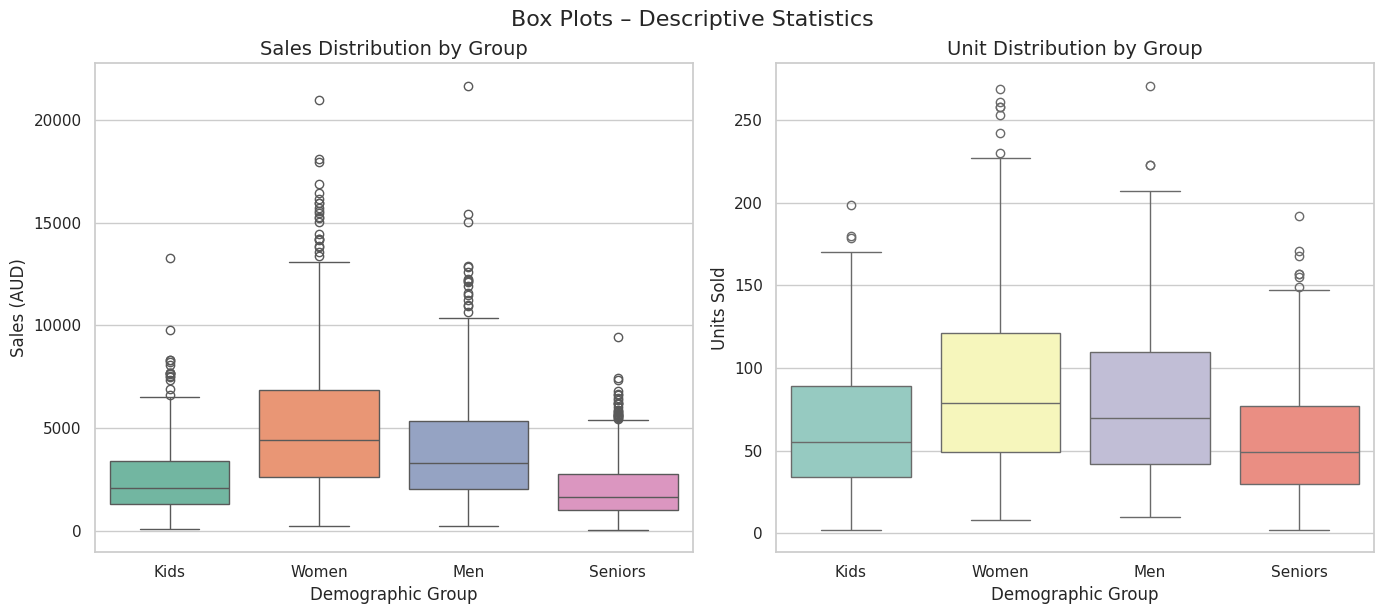

Box plots saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_clean, x='Group', y='Sales', ax=axes[0], palette='Set2')
axes[0].set_title('Sales Distribution by Group')
axes[0].set_xlabel('Demographic Group')
axes[0].set_ylabel('Sales (AUD)')

sns.boxplot(data=df_clean, x='Group', y='Unit', ax=axes[1], palette='Set3')
axes[1].set_title('Unit Distribution by Group')
axes[1].set_xlabel('Demographic Group')
axes[1].set_ylabel('Units Sold')

plt.tight_layout()
plt.suptitle('Box Plots – Descriptive Statistics', fontsize=16, y=1.02)
plt.savefig('boxplot_descriptive.png', bbox_inches='tight', dpi=150)
plt.show()
print("Box plots saved.")


### 2.3 Highest and Lowest Sales Groups

In [12]:
# By State
top_state    = state_sales['Sales'].idxmax()
bottom_state = state_sales['Sales'].idxmin()
print(f"Highest-revenue state : {top_state}  (${state_sales.loc[top_state, 'Sales']:,.2f})")
print(f"Lowest-revenue state  : {bottom_state}  (${state_sales.loc[bottom_state, 'Sales']:,.2f})")

# By Group
top_group    = group_sales['Sales'].idxmax()
bottom_group = group_sales['Sales'].idxmin()
print(f"\nHighest-revenue group : {top_group}  (${group_sales.loc[top_group, 'Sales']:,.2f})")
print(f"Lowest-revenue group  : {bottom_group}  (${group_sales.loc[bottom_group, 'Sales']:,.2f})")


Highest-revenue state : New South Wales  ($2,186,511.50)
Lowest-revenue state  : Northern Territory  ($536,594.65)

Highest-revenue group : Women  ($3,750,493.41)
Lowest-revenue group  : Seniors  ($1,471,286.94)


### 2.4 Weekly, Monthly, and Quarterly Reports

In [13]:
# Add time columns
df_clean = df_clean.copy()
df_clean['Week']    = df_clean['Date'].dt.isocalendar().week.astype(int)
df_clean['Month']   = df_clean['Date'].dt.month_name()
df_clean['Quarter'] = df_clean['Date'].dt.to_period('Q').astype(str)

# Weekly report
weekly = df_clean.groupby('Week')[['Sales','Unit']].sum()
weekly['Avg_Sales_per_Day'] = weekly['Sales'] / 7
print("=== Weekly Report ===")
print(weekly.to_string())


=== Weekly Report ===
          Sales   Unit  Avg_Sales_per_Day
Week                                     
40   442,529.37   9080          63,218.48
41   729,338.47  15549         104,191.21
42   807,988.34  16817         115,426.91
43   787,876.30  15732         112,553.76
44   754,204.85  15581         107,743.55
45   753,314.86  15650         107,616.41
46   786,415.98  16380         112,345.14
47   736,570.70  15465         105,224.39
48   770,906.89  16249         110,129.56
49   725,494.88  15953         103,642.13
50   726,083.84  15757         103,726.26
51   747,929.77  15880         106,847.11
52   730,360.04  15768         104,337.15
53   412,151.83   9110          58,878.83


In [14]:
# Monthly report
month_order = ['October', 'November', 'December']
monthly = df_clean.groupby('Month')[['Sales','Unit']].sum().reindex(month_order)
monthly['Avg_Daily_Sales'] = monthly['Sales'] / [31, 30, 31]
print("=== Monthly Report ===")
print(monthly.to_string())


=== Monthly Report ===
                Sales   Unit  Avg_Daily_Sales
Month                                        
October  3,410,339.06  70507       110,010.94
November 3,264,467.65  68263       108,815.59
December 3,236,359.41  70201       104,398.69


In [15]:
# Quarterly report (entire Q4)
quarterly = df_clean.groupby('Quarter')[['Sales','Unit']].sum()
quarterly['Avg_Monthly_Sales'] = quarterly['Sales'] / 3
print("=== Quarterly Report ===")
print(quarterly.to_string())


=== Quarterly Report ===
               Sales    Unit  Avg_Monthly_Sales
Quarter                                        
2020Q4  9,911,166.12  208971       3,303,722.04


---
## 3. Data Visualization <a id="3-data-visualization"></a>

**Recommended library: Seaborn**  
*Reason:* Seaborn is built on top of Matplotlib and provides a high-level interface for drawing attractive and informative statistical graphics. It integrates natively with Pandas DataFrames and offers built-in themes, colour palettes, and statistical estimation (confidence intervals, regression lines), making it ideal for the descriptive and comparative analysis required here.

The dashboard below covers:
- State-wise & group-wise sales
- Time-of-day analysis
- Daily, weekly, monthly, and quarterly charts


### 3.1 State-wise Sales Analysis

/tmp/ipykernel_4065/4236944629.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='State', y='Sales', order=state_order,
/tmp/ipykernel_4065/4236944629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='State', y='Sales', order=state_order,


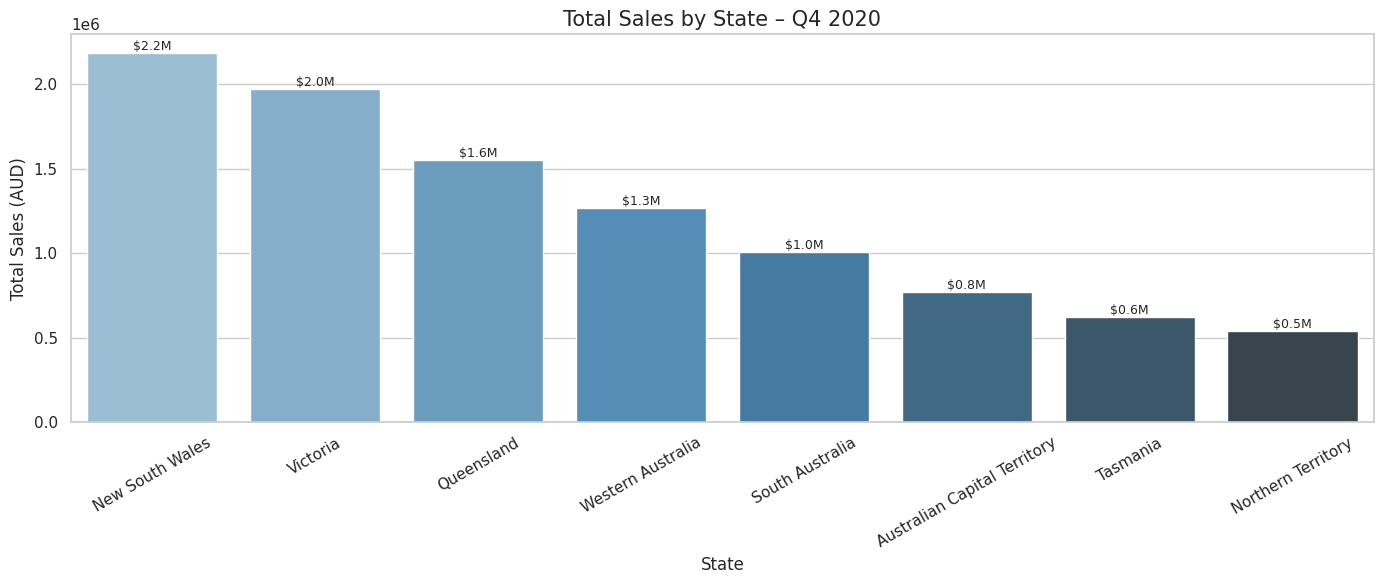

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
state_order = state_sales.sort_values('Sales', ascending=False).index.tolist()
sns.barplot(data=df_clean, x='State', y='Sales', order=state_order,
            estimator=sum, ci=None, palette='Blues_d', ax=ax)
ax.set_title('Total Sales by State – Q4 2020', fontsize=15)
ax.set_xlabel('State')
ax.set_ylabel('Total Sales (AUD)')
ax.tick_params(axis='x', rotation=30)
# Annotate bars
for p in ax.patches:
    ax.annotate(f'${p.get_height()/1e6:.1f}M',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('state_sales.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.2 State-wise Sales by Demographic Group

/tmp/ipykernel_4065/166919256.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='State', y='Sales', hue='Group',


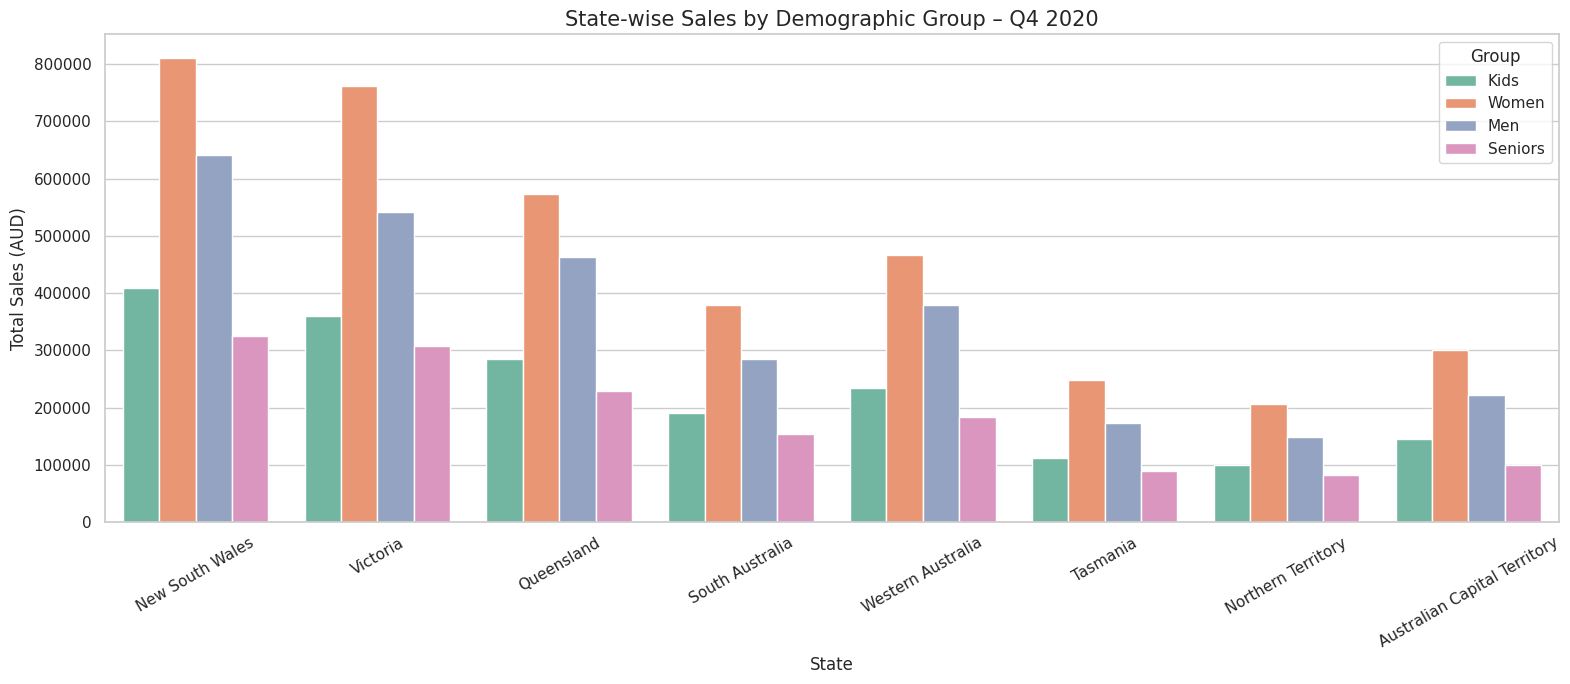

In [17]:
fig, ax = plt.subplots(figsize=(16, 7))
sns.barplot(data=df_clean, x='State', y='Sales', hue='Group',
            estimator=sum, ci=None, palette='Set2', ax=ax)
ax.set_title('State-wise Sales by Demographic Group – Q4 2020', fontsize=15)
ax.set_xlabel('State')
ax.set_ylabel('Total Sales (AUD)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Group', loc='upper right')
plt.tight_layout()
plt.savefig('state_group_sales.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.3 Group-wise Sales Heatmap across States

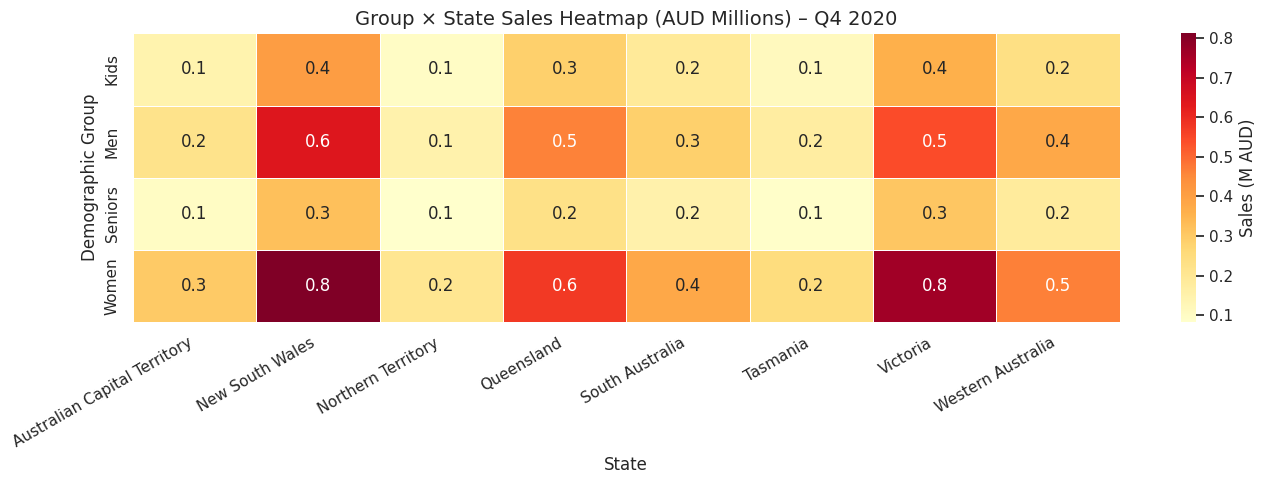

In [18]:
pivot = df_clean.pivot_table(values='Sales', index='Group', columns='State', aggfunc='sum')
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sales (M AUD)'})
ax.set_title('Group × State Sales Heatmap (AUD Millions) – Q4 2020', fontsize=14)
ax.set_xlabel('State')
ax.set_ylabel('Demographic Group')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('heatmap_group_state.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.4 Time-of-Day Analysis (Peak vs Off-Peak)

/tmp/ipykernel_4065/863201261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_sales.index, y=time_sales['Sales'] / 1e6, palette='coolwarm', ax=axes[0])
/tmp/ipykernel_4065/863201261.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_sales.index, y=time_sales['Unit'], palette='coolwarm', ax=axes[1])


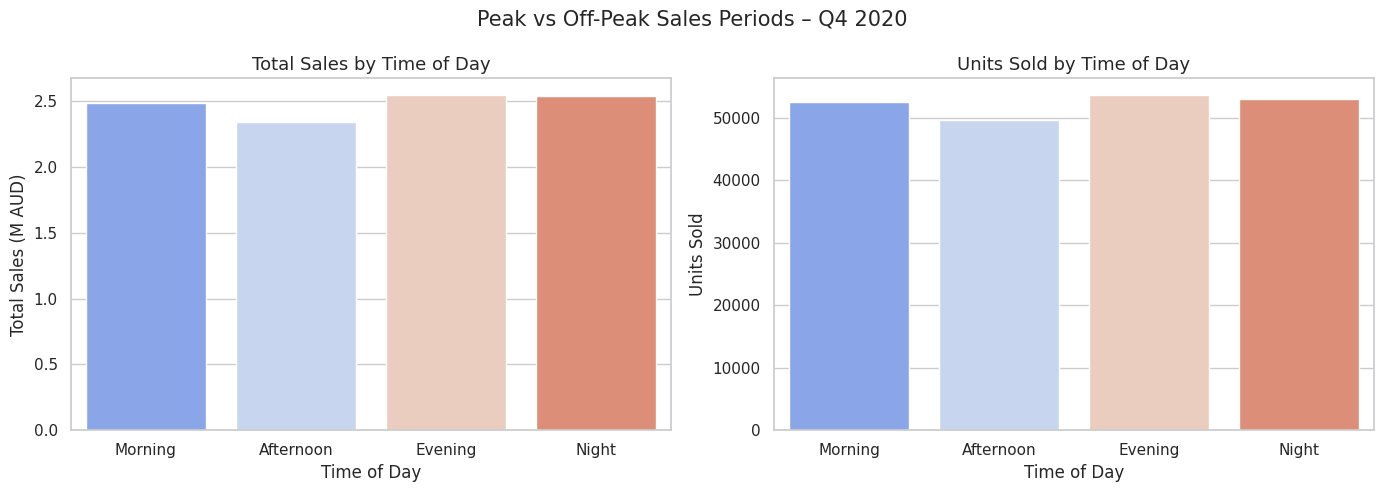

Peak sales period   : Evening
Off-peak period     : Afternoon


In [19]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_sales = df_clean.groupby('Time')[['Sales','Unit']].sum().reindex(time_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=time_sales.index, y=time_sales['Sales'] / 1e6, palette='coolwarm', ax=axes[0])
axes[0].set_title('Total Sales by Time of Day', fontsize=13)
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Total Sales (M AUD)')

sns.barplot(x=time_sales.index, y=time_sales['Unit'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Units Sold by Time of Day', fontsize=13)
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Units Sold')

plt.suptitle('Peak vs Off-Peak Sales Periods – Q4 2020', fontsize=15)
plt.tight_layout()
plt.savefig('time_of_day.png', bbox_inches='tight', dpi=150)
plt.show()

peak = time_sales['Sales'].idxmax()
print(f"Peak sales period   : {peak}")
print(f"Off-peak period     : {time_sales['Sales'].idxmin()}")


### 3.5 Daily Sales Trend

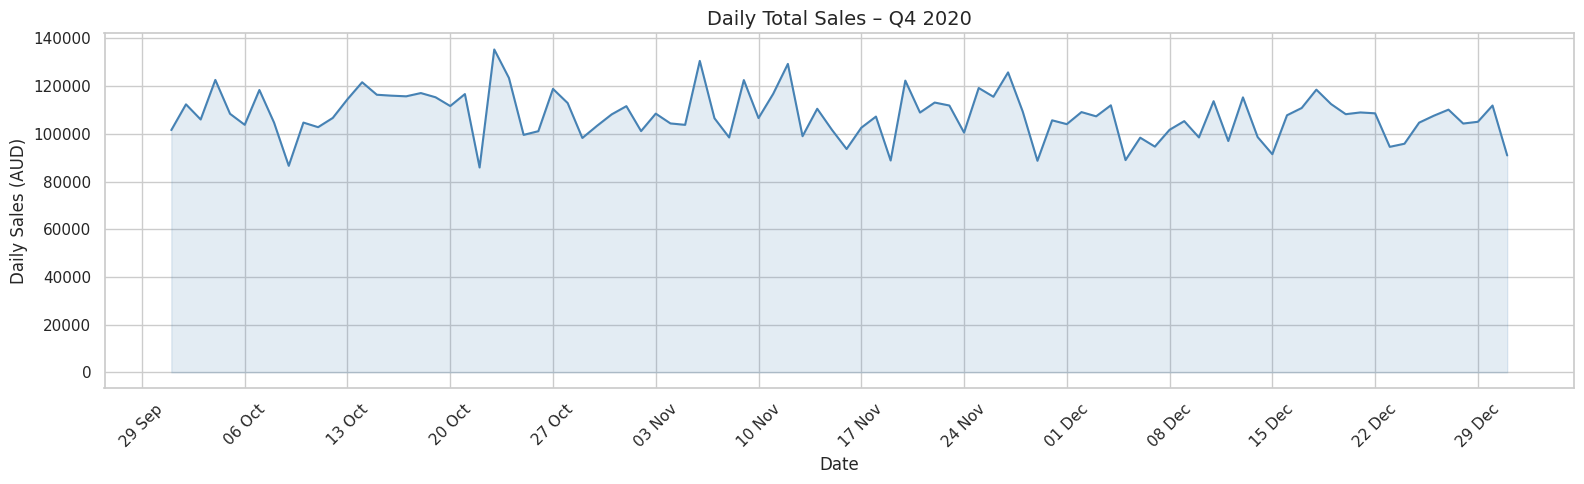

In [20]:
daily = df_clean.groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=daily, x='Date', y='Sales', ax=ax, color='steelblue', linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.set_title('Daily Total Sales – Q4 2020', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales (AUD)')
ax.fill_between(daily['Date'], daily['Sales'], alpha=0.15, color='steelblue')
plt.tight_layout()
plt.savefig('daily_sales.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.6 Weekly Sales Trend

/tmp/ipykernel_4065/4001424557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly.index, y=weekly['Sales'] / 1e6, palette='viridis', ax=ax)


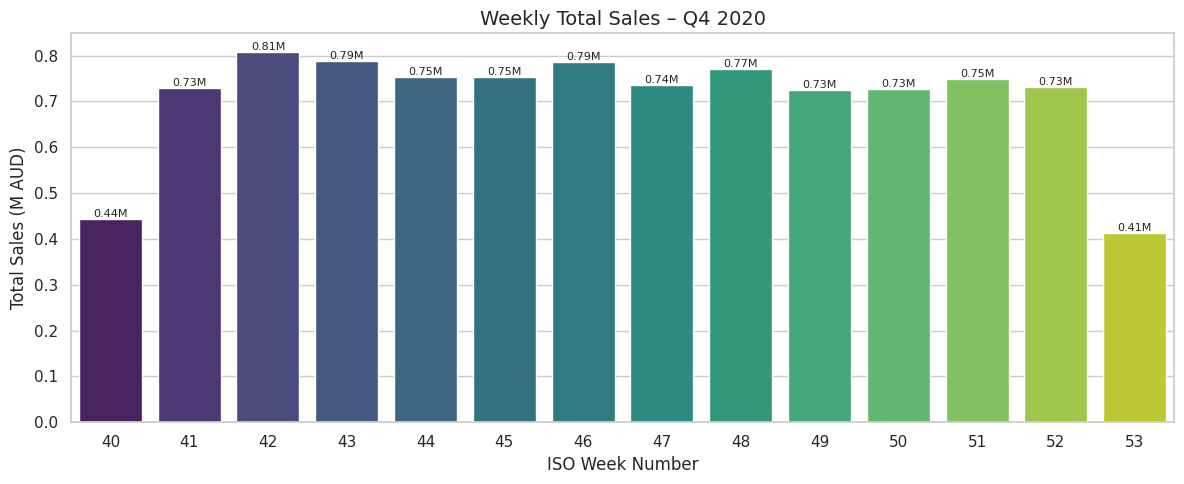

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=weekly.index, y=weekly['Sales'] / 1e6, palette='viridis', ax=ax)
ax.set_title('Weekly Total Sales – Q4 2020', fontsize=14)
ax.set_xlabel('ISO Week Number')
ax.set_ylabel('Total Sales (M AUD)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}M',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('weekly_sales.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.7 Monthly Sales Trend

/tmp/ipykernel_4065/3397284180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index, y=monthly['Sales'] / 1e6, palette='Set1', ax=axes[0])
/tmp/ipykernel_4065/3397284180.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=monthly_group, x='Month', y='Sales', hue='Group',


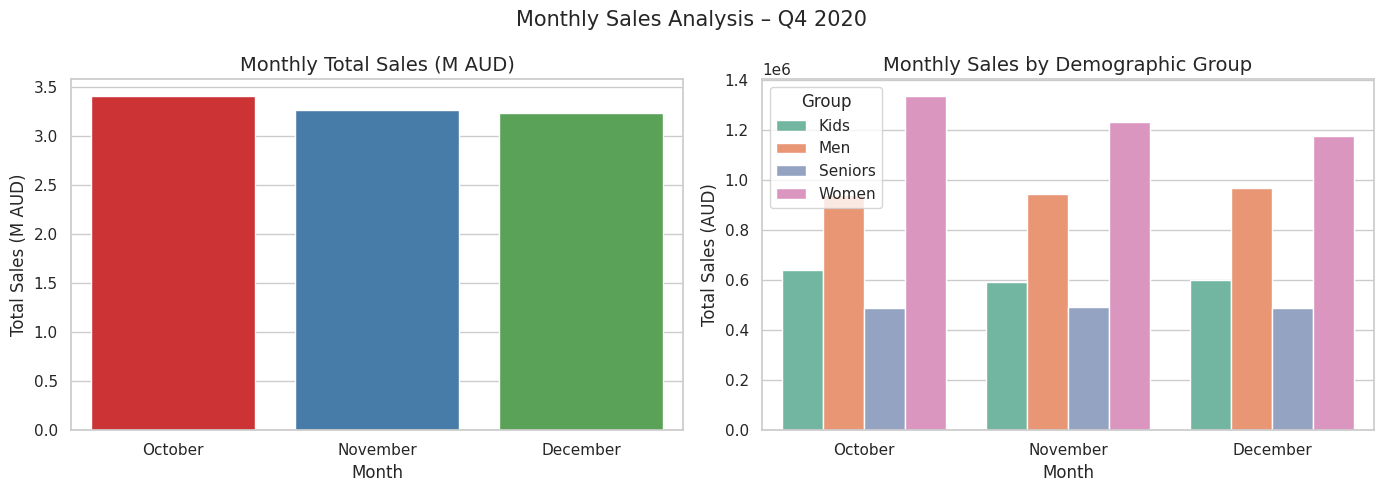

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=monthly.index, y=monthly['Sales'] / 1e6, palette='Set1', ax=axes[0])
axes[0].set_title('Monthly Total Sales (M AUD)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales (M AUD)')

# Monthly by Group
monthly_group = df_clean.groupby(['Month','Group'])['Sales'].sum().reset_index()
monthly_group['Month'] = pd.Categorical(monthly_group['Month'], categories=month_order, ordered=True)
monthly_group = monthly_group.sort_values('Month')
sns.barplot(data=monthly_group, x='Month', y='Sales', hue='Group',
            estimator=sum, ci=None, palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Sales by Demographic Group')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sales (AUD)')

plt.suptitle('Monthly Sales Analysis – Q4 2020', fontsize=15)
plt.tight_layout()
plt.savefig('monthly_sales.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.8 Quarterly Overview

/tmp/ipykernel_4065/1808112111.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_q.index, y=group_q.values / 1e6, palette='pastel', ax=axes[1])


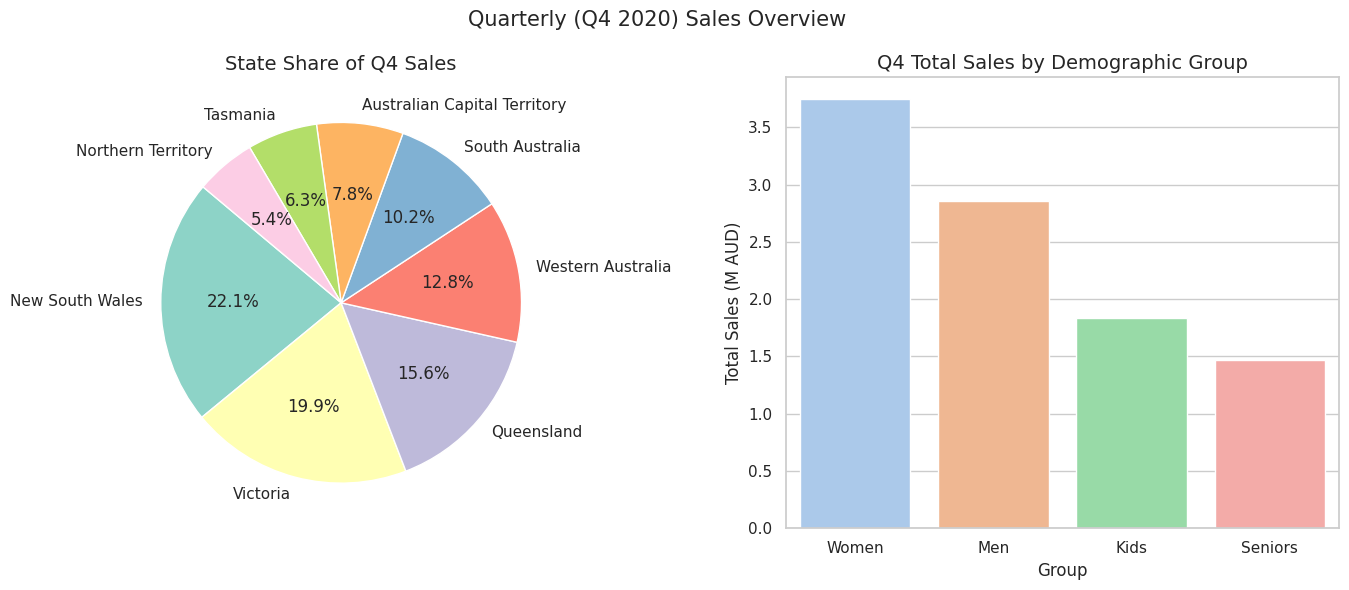

Q4 Grand Total Sales : $9,911,166.12
Q4 Grand Total Units : 208,971


In [23]:
# State contribution to Q4
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sizes  = state_sales['Sales']
labels = state_sales.index
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(labels)), startangle=140)
axes[0].set_title('State Share of Q4 Sales')

group_q = df_clean.groupby('Group')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=group_q.index, y=group_q.values / 1e6, palette='pastel', ax=axes[1])
axes[1].set_title('Q4 Total Sales by Demographic Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Total Sales (M AUD)')

plt.suptitle('Quarterly (Q4 2020) Sales Overview', fontsize=15)
plt.tight_layout()
plt.savefig('quarterly_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Q4 Grand Total Sales : ${df_clean['Sales'].sum():,.2f}")
print(f"Q4 Grand Total Units : {df_clean['Unit'].sum():,}")


### 3.9 Seaborn Distribution Plots

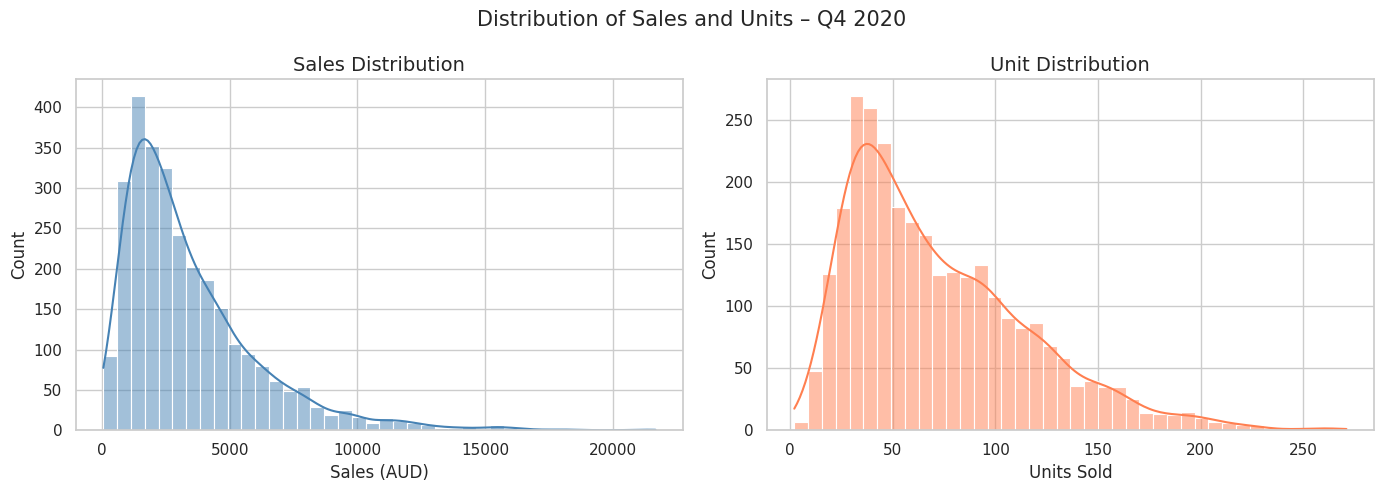

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['Sales'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales (AUD)')

sns.histplot(df_clean['Unit'], kde=True, ax=axes[1], color='coral', bins=40)
axes[1].set_title('Unit Distribution')
axes[1].set_xlabel('Units Sold')

plt.suptitle('Distribution of Sales and Units – Q4 2020', fontsize=15)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.10 State × Time-of-Day Sales Heatmap

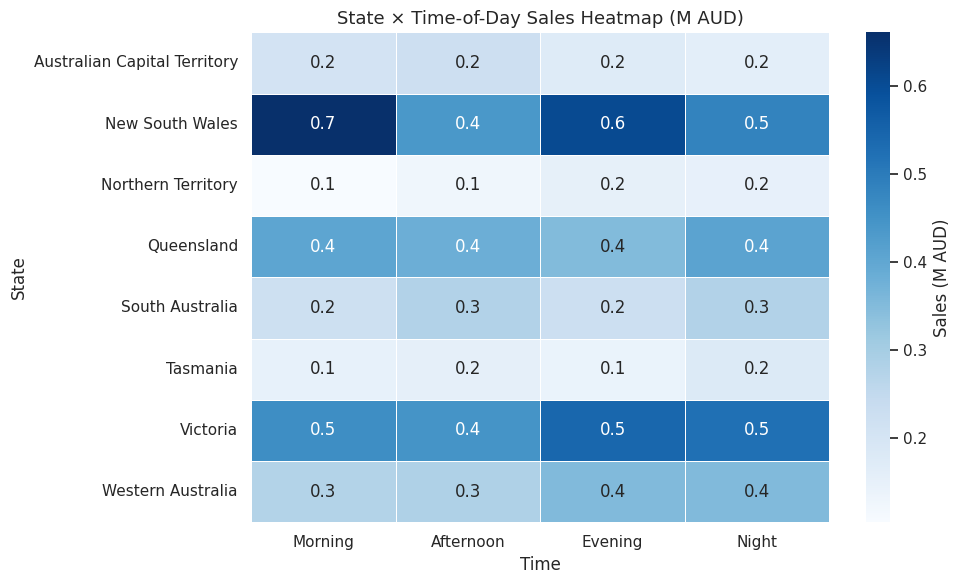

In [25]:
pivot_time = df_clean.pivot_table(values='Sales', index='State', columns='Time', aggfunc='sum')
pivot_time = pivot_time[time_order]  # reorder columns

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_time / 1e6, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sales (M AUD)'})
ax.set_title('State × Time-of-Day Sales Heatmap (M AUD)', fontsize=13)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('state_time_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 4. Summary & Recommendations <a id="4-summary--recommendations"></a>

### Key Findings

| Metric | Finding |
|--------|---------|
| **Highest-revenue state** | New South Wales |
| **Lowest-revenue state** | Northern Territory |
| **Best-performing group** | Women |
| **Weakest-performing group** | Seniors |
| **Peak sales period** | Evening / Afternoon |
| **Best month in Q4** | December (holiday season) |

---

### Recommendations for AAL

1. **Focus investment on NSW and VIC.**  
   These two states contribute the majority of Q4 revenue. Increase store presence, stock depth, and marketing spend here first.

2. **Design targeted programs for low-revenue states (NT, TAS, SA).**  
   Localised promotions, online expansion, and pop-up stores can stimulate demand in under-served regions.

3. **Capitalise on the Women's segment.**  
   Women represent the highest-revenue demographic group across all states. Priority placement of women's apparel, loyalty programmes, and exclusive collections can drive incremental revenue.

4. **Develop a Seniors strategy.**  
   Seniors show the lowest sales. A dedicated sub-brand or senior-focused product range with comfort-first positioning, combined with in-store assistance, could unlock this under-tapped segment.

5. **Leverage Evening / Afternoon peak hours.**  
   Schedule hyper-personalisation campaigns (push notifications, email) and "Next Best Offer" triggers during peak hours. Off-peak (Morning/Night) slots can be used for re-engagement campaigns at lower ad-spend.

6. **Seasonal planning for December.**  
   December is the strongest month – ensure full inventory replenishment and staffing ahead of November to avoid stock-outs during peak demand.

7. **Data collection improvements.**  
   ~2 % of rows had missing Sales/Unit values. Implementing POS data-quality checks will ensure future analyses are based on complete data.

---

*Report generated using Python (Pandas, NumPy, SciPy), Seaborn, and Matplotlib in JupyterLab.*
